# Notebook 1 — NLP clásico con IMDB
## Limpieza, vectorización y clasificación de sentimientos

En este notebook vamos a construir un clasificador de sentimientos usando el dataset **IMDB** de Hugging Face.

La idea no es solo ejecutar código, sino **tomar decisiones reales de NLP**:

```text
texto bruto → análisis exploratorio → limpieza → vectorización → modelo → evaluación → interpretación → mejora
```

Trabajaremos con técnicas clásicas:

- Limpieza y normalización de texto.
- Tokenización.
- Stop words y negación.
- Bag-of-Words.
- N-gramas.
- TF-IDF.
- Clasificación supervisada.
- Análisis de errores.

> Duración estimada: **75-90 minutos**.

## 0. Instalación y carga de librerías

En Google Colab instalamos `datasets` para descargar IMDB desde Hugging Face.

In [1]:
!pip -q install datasets

In [2]:
import re
import html
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_colwidth", 180)

## 1. Carga del dataset IMDB desde Hugging Face

Usaremos `load_dataset('imdb')`.

Cada ejemplo contiene:

- `text`: reseña de una película.
- `label`: sentimiento.
  - `0` = negativa.
  - `1` = positiva.

Para que la práctica vaya fluida en clase, usaremos una muestra del dataset completo.

In [3]:
# Carga del dataset completo desde Hugging Face

dataset_train = load_dataset("imdb", split="train")
dataset_test = load_dataset("imdb", split="test")

# Renombramos label -> labels para seguir una convención frecuente en librerías de entrenamiento
if "label" in dataset_train.column_names:
    dataset_train = dataset_train.rename_column("label", "labels")
if "label" in dataset_test.column_names:
    dataset_test = dataset_test.rename_column("label", "labels")

train_df_full = pd.DataFrame(dataset_train)
test_df_full = pd.DataFrame(dataset_test)

# Muestras para que el entrenamiento sea rápido en clase
N_TRAIN = 6000
N_TEST = 2000

train_df = train_df_full.sample(N_TRAIN, random_state=RANDOM_STATE).reset_index(drop=True)
test_df = test_df_full.sample(N_TEST, random_state=RANDOM_STATE).reset_index(drop=True)

label_map = {0: "negativa", 1: "positiva"}
train_df["sentiment"] = train_df["labels"].map(label_map)
test_df["sentiment"] = test_df["labels"].map(label_map)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
train_df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train: (6000, 3)
Test: (2000, 3)


,text,labels,sentiment
0,"Dumb is as dumb does, in this thoroughly uninteresting, supposed black comedy. Essentially what starts out as Chris Klein trying to maintain a low profile, eventually morphs in...",0,negativa
1,I dug out from my garage some old musicals and this is another one of my favorites. It was written by Jay Alan Lerner and directed by Vincent Minelli. It won two Academy Awards...,1,positiva
2,"After watching this movie I was honestly disappointed - not because of the actors, story or directing - I was disappointed by this film advertisements.<br /><br />The trailers ...",0,negativa
3,This movie was nominated for best picture but lost out to Casablanca but Paul Lukas beat out Humphrey Bogart for best actor. I don't see why Lucile Watson was nominated for bes...,1,positiva
4,"Just like Al Gore shook us up with his painfully honest and cleverly presented documentary-movie ""An inconvenient truth"", directors Alastair Fothergill and Mark Linfield also r...",1,positiva


## 2. Primer contacto con los datos

Antes de entrenar modelos, necesitamos entender el dataset.

No basta con saber que hay reseñas positivas y negativas. Algunas preguntas importantes son:

- ¿Las clases están balanceadas?
- ¿Las reseñas positivas y negativas tienen longitudes parecidas?
- ¿Hay HTML o ruido?
- ¿Qué palabras aparecen mucho en cada clase?
- ¿Puede haber pistas demasiado fáciles o sesgos?

In [4]:
print("Distribución de clases en train:")
print(train_df["sentiment"].value_counts())
print("Proporción:")
print(train_df["sentiment"].value_counts(normalize=True).round(3))

train_df[["text", "labels", "sentiment"]].sample(3, random_state=RANDOM_STATE)

Distribución de clases en train:
sentiment
positiva    3008
negativa    2992
Name: count, dtype: int64
Proporción:
sentiment
positiva    0.501
negativa    0.499
Name: proportion, dtype: float64


,text,labels,sentiment
1782,"Oh god, what a horrible, horrible film. Meant to be a comment on the state of society, it's just a reflection of the worst of the worst in reality TV. Interstitials hosted by J...",0,negativa
3917,"Yes, even as a fan of shows like survivor and the apprentice, this show is pretty bad. I didn't mind the first couple of shows, but then realizing how pathetic everyone was to ...",0,negativa
221,Not an altogether bad start for the program -- but what a slap in the face to real law enforcement. The worst part of the series is that it attempts to bill itself as reality f...,0,negativa


### TODO 1 — Análisis exploratorio

Completa el análisis de longitud de las reseñas y responde con evidencias.

Tareas:

1. Crea tres columnas en `train_df`:
   - `num_chars`: número de caracteres.
   - `num_words`: número aproximado de palabras.
   - `num_sentences`: número aproximado de frases, separando por `.`, `!` y `?`.
2. Calcula la media, mediana, mínimo y máximo de `num_words` por clase.
3. Visualiza la distribución de longitudes.
4. Responde:
   - ¿Hay diferencias claras entre reseñas positivas y negativas?
   - ¿Podría la longitud ser una pista para el modelo?
   - ¿Qué problema puede causar una reseña extremadamente larga?

> Pista: usa `.str.len()`, `.str.split()` y `groupby()`.

In [14]:
# TODO 1.1: crea las columnas de longitud

train_df["num_chars"] = train_df["text"].str.len()        # número de caracteres del texto
train_df["num_words"] = train_df["text"].str.split().str.len()  # número de palabras aproximado
train_df["num_sentences"] = train_df["text"].str.split('.').str.len() # número aproximado de frases

# Cuando lo hayas completado, estas comprobaciones deberían pasar
assert train_df["num_chars"].notna().all(), "num_chars todavía tiene valores vacíos"
assert train_df["num_words"].notna().all(), "num_words todavía tiene valores vacíos"
assert train_df["num_sentences"].notna().all(), "num_sentences todavía tiene valores vacíos"

train_df[["text", "sentiment", "num_chars", "num_words", "num_sentences"]].head()

,text,sentiment,num_chars,num_words,num_sentences
0,"Dumb is as dumb does, in this thoroughly uninteresting, supposed black comedy. Essentially what starts out as Chris Klein trying to maintain a low profile, eventually morphs in...",negativa,655,115,7
1,I dug out from my garage some old musicals and this is another one of my favorites. It was written by Jay Alan Lerner and directed by Vincent Minelli. It won two Academy Awards...,positiva,796,143,10
2,"After watching this movie I was honestly disappointed - not because of the actors, story or directing - I was disappointed by this film advertisements.<br /><br />The trailers ...",negativa,1312,229,15
3,This movie was nominated for best picture but lost out to Casablanca but Paul Lukas beat out Humphrey Bogart for best actor. I don't see why Lucile Watson was nominated for bes...,positiva,775,149,9
4,"Just like Al Gore shook us up with his painfully honest and cleverly presented documentary-movie ""An inconvenient truth"", directors Alastair Fothergill and Mark Linfield also r...",positiva,2025,349,12


In [15]:
# TODO 1.2: "mean", "median", "min" y "max" por clase

resumen_longitud = train_df.groupby('sentiment')['num_words'].agg(['mean', 'median', 'min', 'max'])
resumen_longitud

,mean,median,min,max
sentiment,,,,
negativa,237.890709,179.5,10,1021
positiva,232.961104,172.0,22,1076


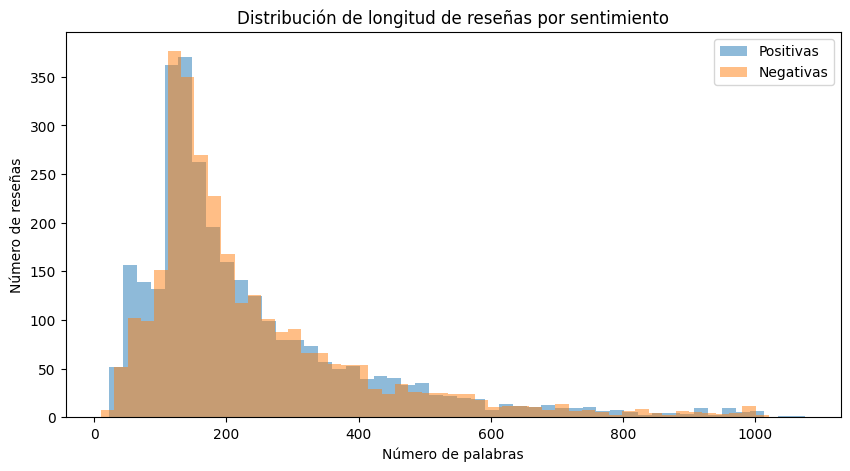

In [17]:
import matplotlib.pyplot as plt

# TODO 1.3: representa la distribución de palabras por clase
# Recomendación: usa un histograma por clase con alpha para comparar.

plt.figure(figsize=(10, 5))

# TODO: dibuja histograma de reseñas positivas
plt.hist(train_df[train_df['sentiment'] == 'positiva']['num_words'], bins=50, alpha=0.5, label='Positivas')

# TODO: dibuja histograma de reseñas negativas
plt.hist(train_df[train_df['sentiment'] == 'negativa']['num_words'], bins=50, alpha=0.5, label='Negativas')

plt.title("Distribución de longitud de reseñas por sentimiento")
plt.xlabel("Número de palabras")
plt.ylabel("Número de reseñas")
plt.legend()
plt.show()

Escribe aquí tus conclusiones:

- Diferencias entre clases: Noy hay ninguna diferencia clara
- Posible efecto de la longitud: La longitud por si sola no será útil al ser un espejo
- Riesgos de textos demasiado largos: Ralentizan el entrenamiento

## 3. Baseline no inteligente: clasificador mayoritario

Antes de entrenar un modelo de NLP, necesitamos un punto de comparación.

Un baseline muy simple es predecir siempre la clase más frecuente.

Si nuestro modelo no supera claramente este baseline, no hemos aprendido mucho.

In [18]:
X_train_raw = train_df["text"]
y_train = train_df["labels"]
X_test_raw = test_df["text"]
y_test = test_df["labels"]

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_raw, y_train)
y_pred_baseline = baseline.predict(X_test_raw)

print("Accuracy baseline:", accuracy_score(y_test, y_pred_baseline))
print("F1 macro baseline:", f1_score(y_test, y_pred_baseline, average="macro"))

Accuracy baseline: 0.48
F1 macro baseline: 0.32432432432432434


## 4. Baseline humano-reglado: palabras positivas y negativas

Antes de usar Machine Learning, vamos a crear un clasificador con reglas simples.

Idea:

- Si una reseña contiene más palabras positivas que negativas → positiva.
- Si contiene más palabras negativas que positivas → negativa.
- Si hay empate → clase por defecto.

Esto sirve para entender por qué NLP no es tan trivial:

- Una palabra puede aparecer en contexto contrario.
- La negación cambia el significado.
- Una reseña larga puede tener opiniones mixtas.
- Algunas palabras dependen del dominio.

### TODO 2 — Diseña y evalúa un clasificador basado en reglas

No copies una lista enorme de internet. Piensa en palabras que realmente puedan aparecer en reseñas de películas.

Tareas:

1. Crea dos listas:
   - `palabras_positivas`
   - `palabras_negativas`
2. Implementa `clasificador_reglas(texto)`.
3. Evalúalo en `test_df`.
4. Busca 5 ejemplos donde falle.
5. Explica por qué falla.

Restricción:

- El clasificador debe mirar palabras completas, no substrings. Por ejemplo, `bad` no debería coincidir dentro de otra palabra.

In [23]:
# TODO 2.1: define tus listas de palabras
# Puedes empezar con 8-15 palabras por clase.

palabras_positivas = [
    "good", "great", "excellent", "amazing", "wonderful",
    "fantastic", "best", "love", "perfect", "beautiful",
    "awesome", "brilliant", "enjoyed", "loved"
]

palabras_negativas = [
    "bad", "terrible", "awful", "worst", "boring",
    "stupid", "waste", "poor", "disappointing", "horrible",
    "dull", "predictable", "hate", "terrible"
]

assert len(palabras_positivas) >= 5, "Añade al menos 5 palabras positivas"
assert len(palabras_negativas) >= 5, "Añade al menos 5 palabras negativas"

In [24]:
def tokenizar_simple(texto):
    """Tokenizador básico para el clasificador de reglas."""
    texto = texto.lower()
    texto = re.sub(r"[^a-z']+", " ", texto)
    return texto.split()


def clasificador_reglas(texto):
    """
    TODO 2.2: Implementa el clasificador.
    """
    tokens = tokenizar_simple(texto)
    set_tokens = set(tokens)

    # TODO: cuenta cuántas palabras positivas y negativas aparecen
    # Usamos la intersección para ver qué palabras coinciden entre el texto y nuestras listas
    score_pos = len(set_tokens.intersection(palabras_positivas))
    score_neg = len(set_tokens.intersection(palabras_negativas))

    # TODO: lógica de decisión
    if score_pos > score_neg:
        prediccion = 1
    elif score_neg > score_pos:
        prediccion = 0
    else:
        prediccion = 1 # 1 en caso de empate, como clase por defecto

    return prediccion

# Prueba rápida
clasificador_reglas("This movie was wonderful and amazing")

1

In [25]:
# TODO 2.3: evalúa el clasificador de reglas en test

y_pred_reglas = test_df["text"].apply(clasificador_reglas).values

print("Accuracy reglas:", accuracy_score(y_test, y_pred_reglas))
print("F1 macro reglas:", f1_score(y_test, y_pred_reglas, average="macro"))
print(classification_report(y_test, y_pred_reglas, target_names=["negativa", "positiva"]))

Accuracy reglas: 0.676
F1 macro reglas: 0.6554892053284336
              precision    recall  f1-score   support

    negativa       0.92      0.42      0.57      1040
    positiva       0.60      0.96      0.74       960

    accuracy                           0.68      2000
   macro avg       0.76      0.69      0.66      2000
weighted avg       0.76      0.68      0.65      2000



Mostramos 5 errores del clasificador de reglas

In [26]:
errores_reglas = test_df.copy()
errores_reglas["pred_reglas"] = y_pred_reglas
errores_reglas["pred_reglas_sentiment"] = errores_reglas["pred_reglas"].map(label_map)
errores_reglas = errores_reglas[errores_reglas["labels"] != errores_reglas["pred_reglas"]]

errores_reglas[["text", "sentiment", "pred_reglas_sentiment"]].sample(5, random_state=RANDOM_STATE)

,text,sentiment,pred_reglas_sentiment
1959,"I've read a lot of reviews on the IMDb (well, all five of the ones that have been written at the time that I'm writing this) and I'm surprised at the amount of praise heaped up...",negativa,positiva
721,I went along to this movie with some trepidation; the original is a masterpiece of both writing and acting and unfortunately my fears were realized. This is a humorless piece o...,negativa,positiva
1823,"Asmali Konak has arguably become one of the best TV series to come out of Turkey. With its unique cinematography and visual approach to filming, the series has gained a wide fo...",negativa,positiva
1346,"Joan Fontaine is swept off her feet by the suave Cary Grant. After their marriage, she realizes that her husband is very irresponsible and owes a major gambling debt. It appear...",negativa,positiva
230,"I come from Bangladesh, and here, C.C.Costigan is a goddess of awesome sex. All kidding aside, a friend and I were awake in the middle of the night, watching movies on the Enco...",negativa,positiva


#### Respuesta TODO 2

Explica 2 o 3 patrones de error del clasificador de reglas:

- Error 1: La negación, si hay un "not good at all" va a pillar good y pensará que es positiva
- Error 2: No pilla el sarcasmo
- Error 3: Vocabulario limitado (out-of-vocabulary)

¿Qué tiene que aprender un modelo que tus reglas no capturan?

## 5. Limpieza y normalización de texto

Ahora vamos a preparar el texto para modelos clásicos.

Decisiones típicas:

- Pasar a minúsculas.
- Eliminar HTML (`<br />`).
- Quitar signos de puntuación.
- Mantener o eliminar stop words.
- Preservar negaciones como `not`, `no`, `never`.

En análisis de sentimientos, la negación es muy importante:

```text
not good ≠ good
not bad ≠ bad
```

### TODO 3 — Implementa una limpieza con decisiones justificadas

Tareas:

1. Termina la implementación de `limpiar_texto`.
2. Debe permitir activar/desactivar stop words.
3. Si eliminas stop words, **no elimines negaciones** como `not`, `no`, `nor`, `never`.
4. Compara una misma reseña antes y después.

Preguntas:

- ¿Qué información se pierde al limpiar?
- ¿Qué limpieza puede ser peligrosa para sentimiento?

In [28]:
NEGACIONES = {"no", "not", "nor", "never"}
STOPWORDS_SEGURAS = set(ENGLISH_STOP_WORDS) - NEGACIONES


def limpiar_texto(texto, eliminar_stopwords=False):
    """
    Limpieza básica para modelos clásicos de NLP.
    """
    # Decodificar entidades HTML, por ejemplo &amp;
    texto = html.unescape(texto)

    # Eliminar etiquetas HTML como <br />
    texto = re.sub(r"<.*?>", " ", texto)

    # TODO 3.1: pasa a minúsculas
    texto = texto.lower()

    # Eliminar caracteres que no sean letras o apóstrofes
    texto = re.sub(r"[^a-z']+", " ", texto)

    # Normalizar espacios múltiples
    texto = re.sub(r"\s+", " ", texto).strip()

    # TODO 3.2: elimina stop words, preservando negaciones.
    if eliminar_stopwords:
        # Dividimos el texto en palabras, filtramos y volvemos a unir
        palabras = texto.split()
        palabras_filtradas = [p for p in palabras if p not in STOPWORDS_SEGURAS]
        texto = " ".join(palabras_filtradas)

    return texto

# Prueba
frase_prueba = "This movie wasn't good.<br />I do NOT recommend it!!!"
print("Original:", frase_prueba)
print("Limpio sin stopwords:", limpiar_texto(frase_prueba, eliminar_stopwords=False))
print("Limpio con stopwords:", limpiar_texto(frase_prueba, eliminar_stopwords=True))

Original: This movie wasn't good.<br />I do NOT recommend it!!!
Limpio sin stopwords: this movie wasn't good i do not recommend it
Limpio con stopwords: movie wasn't good not recommend


In [29]:
# TODO 3.3: aplica la limpieza al train y test
# Cuidado: para 6000/2000 ejemplos debería tardar poco.

train_df["clean_text"] = train_df["text"].apply(lambda x: limpiar_texto(x, eliminar_stopwords=True))
test_df["clean_text"] = test_df["text"].apply(lambda x: limpiar_texto(x, eliminar_stopwords=True))

assert train_df["clean_text"].notna().all(), "Falta clean_text en train"
assert test_df["clean_text"].notna().all(), "Falta clean_text en test"

train_df[["text", "clean_text", "sentiment"]].sample(3, random_state=RANDOM_STATE)

,text,clean_text,sentiment
1782,"Oh god, what a horrible, horrible film. Meant to be a comment on the state of society, it's just a reflection of the worst of the worst in reality TV. Interstitials hosted by J...",oh god horrible horrible film meant comment state society it's just reflection worst worst reality tv interstitials hosted jason jones don mckellar obnoxious written tone meant...,negativa
3917,"Yes, even as a fan of shows like survivor and the apprentice, this show is pretty bad. I didn't mind the first couple of shows, but then realizing how pathetic everyone was to ...",yes fan shows like survivor apprentice pretty bad didn't mind couple shows realizing pathetic actually place antics alex aaron giving men bad way cheated dumped choice opportun...,negativa
221,Not an altogether bad start for the program -- but what a slap in the face to real law enforcement. The worst part of the series is that it attempts to bill itself as reality f...,not altogether bad start program slap face real law enforcement worst series attempts reality fare men women dedicate lives enforcement laws deserve better medical school minut...,negativa


## 6. Bag-of-Words y TF-IDF

Ahora convertimos texto en números.

### Bag-of-Words
Cuenta cuántas veces aparece cada palabra o grupo de palabras.

### TF-IDF
Da más peso a términos característicos de un documento y menos peso a términos demasiado comunes.

Vamos a comparar diferentes representaciones.

In [30]:
vectorizadores = {
    "bow_unigram": CountVectorizer(
        ngram_range=(1, 1),
        min_df=2,
        max_df=0.95,
        max_features=20000
    ),
    "bow_uni_bigram": CountVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        max_features=30000
    ),
    "tfidf_uni_bigram": TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        max_features=30000
    ),
}

for nombre, vectorizer in vectorizadores.items():
    assert vectorizer is not None, f"Falta definir el vectorizador {nombre}"

Analizamos la información sobre el vocabulario de cada vectorizador.

In [31]:
info_vectorizadores = []

for nombre, vectorizer in vectorizadores.items():
    X_vec = vectorizer.fit_transform(train_df["clean_text"])
    vocab = vectorizer.get_feature_names_out()

    info_vectorizadores.append({
        "vectorizador": nombre,
        "num_documentos": X_vec.shape[0],
        "num_features": X_vec.shape[1],
        "contiene_not_good": "not good" in vocab,
        "contiene_waste_time": "waste time" in vocab,
        "contiene_great_movie": "great movie" in vocab,
    })

pd.DataFrame(info_vectorizadores)

,vectorizador,num_documentos,num_features,contiene_not_good,contiene_waste_time,contiene_great_movie
0,bow_unigram,6000,20000,False,False,False
1,bow_uni_bigram,6000,30000,True,True,True
2,tfidf_uni_bigram,6000,30000,True,True,True


In [32]:
for nombre, vectorizer in vectorizadores.items():
    vocab = vectorizer.get_feature_names_out()
    print("\n", "="*80)
    print(nombre)
    print("Primeras 30 features:")
    print(vocab[:30])
    print("30 features aleatorias:")
    print(np.random.choice(vocab, size=30, replace=False))


bow_unigram
Primeras 30 features:
['aardman' 'aaron' 'abandon' 'abandoned' 'abandoning' 'abandonment'
 'abandons' 'abbott' 'abby' 'abc' 'abducted' 'abduction' 'abe' 'abetted'
 'abhay' 'abhorrence' 'abhorrent' 'abiding' 'abigail' 'abilities'
 'ability' 'abject' 'able' 'ably' 'abnormal' 'aboard' 'abominable'
 'abomination' 'aboriginal' 'aborigine']
30 features aleatorias:
['locale' 'brody' 'hostages' 'awkward' 'psyche' 'narrates' 'marion'
 'clinton' 'wordy' 'hat' 'contention' 'gushing' 'sludge' 'skies' 'orlando'
 'economically' 'warm' 'specialized' 'harry' 'aggressive' 'juggling'
 'glory' 'uttering' 'supernatural' 'incidences' 'slo' 'showcases' 'klaus'
 'vampiric' 'cornball']

bow_uni_bigram
Primeras 30 features:
['aaron' 'abandon' 'abandoned' 'abandoning' 'abandonment' 'abbott' 'abc'
 'abducted' 'abe' 'abetted' 'abhay' 'abhay deol' 'abiding' 'abigail'
 'abilities' 'ability' 'able' 'able capture' 'able enjoy' 'able hold'
 'able make' 'able produce' 'able sit' 'able stand' 'able walk'
 '

#### Respuesta TODO 4

Compara las representaciones:

- ¿Qué gana el modelo al usar bigramas?
- ¿Qué coste tiene usar bigramas?
- ¿Por qué TF-IDF podría ser mejor que contar palabras?
- ¿Qué vectorizador elegirías antes de entrenar y por qué?

## 7. Entrenamiento de modelos clásicos

Vamos a entrenar varios modelos y compararlos.

Combinaremos:

- Vectorizadores: Bag-of-Words y TF-IDF.
- Modelos: Naive Bayes y Regresión Logística.

No buscamos solo el número más alto. Queremos entender:

- Qué configuración funciona mejor.
- Cuánto mejora respecto al baseline.
- Qué errores siguen apareciendo.

In [33]:
def evaluar_modelo(nombre, pipeline, X_train, y_train, X_test, y_test):
    """Entrena un pipeline y devuelve métricas principales."""
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    return {
        "nombre": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "pipeline": pipeline,
        "y_pred": y_pred,
    }

### TODO 5 — Diseña una pequeña batería de experimentos

Tareas:

1. Crea al menos 4 experimentos combinando vectorizador + modelo.
2. Todos deben usar el mismo train/test para que la comparación sea justa.
3. Guarda accuracy y F1 macro.
4. Ordena resultados por F1 macro.
5. Elige un modelo ganador y justifica por qué.

Condición:

- Al menos un experimento debe usar bigramas.
- Al menos un experimento debe usar TF-IDF.
- Al menos un experimento debe usar Naive Bayes (`MultinomialNB`).
- Al menos un experimento debe usar Regresión Logística (`LogisticRegression`).

In [34]:
# TODO 5.1: define tus experimentos
# Investiga como funcionan los parámetros min_df, max_df, ngram_range y max_features de CountVectorizer. Puedes modificar esos y los que consideres.

experimentos = {
    # 1. El experimento base que ya venía (Unigramas + CountVectorizer + Naive Bayes)
    "bow_nb_unigram": Pipeline([
        ("vectorizer", CountVectorizer()),
        ("model", MultinomialNB())
    ]),

    # 2. Cumplimos la condición de usar BIGRAMAS (y unigramas) con CountVectorizer
    "bow_nb_bigram": Pipeline([
        ("vectorizer", CountVectorizer(ngram_range=(1, 2))),
        ("model", MultinomialNB())
    ]),

    # 3. Cumplimos las condiciones de usar TF-IDF y Regresión Logística
    "tfidf_lr_unigram": Pipeline([
        ("vectorizer", TfidfVectorizer()),
        ("model", LogisticRegression(max_iter=1000)) # max_iter alto para asegurar convergencia
    ]),

    # 4. Combinamos todo: TF-IDF + Bigramas + Regresión Logística (Suele ser el modelo más fuerte)
    # Usamos min_df y max_df para filtrar palabras demasiado raras o demasiado comunes
    "tfidf_lr_bigram": Pipeline([
        ("vectorizer", TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.9)),
        ("model", LogisticRegression(max_iter=1000))
    ])
}

assert len(experimentos) >= 4, "Debes definir al menos 4 experimentos"

Ejecutamos los experimentos

In [35]:
resultados = []
modelos_entrenados = {}

for nombre, pipeline in experimentos.items():
    print(f"Entrenando {nombre}...")
    resultado = evaluar_modelo(
        nombre,
        pipeline,
        train_df["clean_text"],
        y_train,
        test_df["clean_text"],
        y_test
    )
    resultados.append({
        "nombre": resultado["nombre"],
        "accuracy": resultado["accuracy"],
        "f1_macro": resultado["f1_macro"],
    })
    modelos_entrenados[nombre] = resultado

resultados_df = pd.DataFrame(resultados).sort_values("f1_macro", ascending=False)
resultados_df

Entrenando bow_nb_unigram...
Entrenando bow_nb_bigram...
Entrenando tfidf_lr_unigram...
Entrenando tfidf_lr_bigram...


,nombre,accuracy,f1_macro
2,tfidf_lr_unigram,0.8540,0.853971
3,tfidf_lr_bigram,0.8515,0.851469
1,bow_nb_bigram,0.8260,0.824242
0,bow_nb_unigram,0.8185,0.817001


Seleccionamos el mejor modelo según F1-macro.

Mejor modelo: tfidf_lr_unigram
              precision    recall  f1-score   support

    negativa       0.88      0.83      0.86      1040
    positiva       0.83      0.88      0.85       960

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.86      0.85      0.85      2000



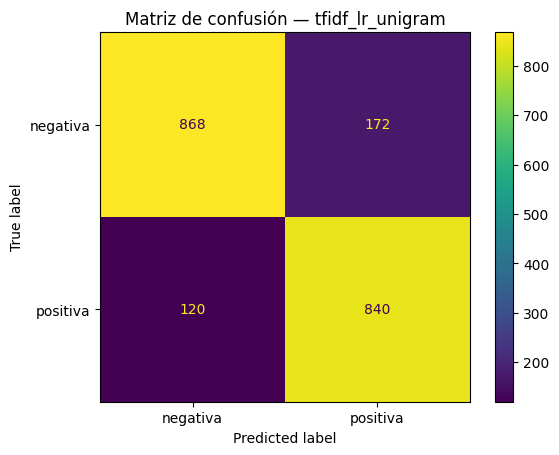

In [36]:
mejor_nombre = resultados_df.iloc[0]["nombre"]

assert mejor_nombre in modelos_entrenados, "mejor_nombre debe ser una clave de modelos_entrenados"

mejor = modelos_entrenados[mejor_nombre]
y_pred_best = mejor["y_pred"]

print("Mejor modelo:", mejor_nombre)
print(classification_report(y_test, y_pred_best, target_names=["negativa", "positiva"]))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=["negativa", "positiva"])
disp.plot(values_format="d")
plt.title(f"Matriz de confusión — {mejor_nombre}")
plt.show()

#### Respuesta TODO 5

- Mejor configuración:
- ¿Mejora respecto al baseline?

• Por qué gana TF-IDF: Porque da más valor a las palabras que realmente expresan sentimiento y penaliza las palabras comunes (como "movie" o "film") que no aportan información.

• Por qué gana Regresión Logística: Porque evalúa el peso de las palabras en conjunto. Naive Bayes suele ser peor porque asume, de forma irreal, que las palabras no tienen relación entre sí.

• Por qué Unigramas y no Bigramas: Porque los bigramas multiplican el tamaño del diccionario, creando demasiadas variables irrelevantes. Esto provoca que el modelo se sobreajuste (overfitting) en los datos de entrenamiento y falle más en el test. Los unigramas son más simples y generalizan mejor.

## 8. Análisis de errores

Un buen proyecto de NLP no termina al mirar accuracy.

Hay que abrir ejemplos concretos y preguntarse:

- ¿Qué ha fallado?
- ¿El texto era ambiguo?
- ¿Había ironía?
- ¿Había una negación difícil?
- ¿La etiqueta humana parece discutible?
- ¿Falta contexto?

In [37]:
# TODO 7.1: crea dataframe de errores

eval_df = test_df.copy()
eval_df["pred"] = y_pred_best
eval_df["pred_sentiment"] = eval_df["pred"].map(label_map)
eval_df["correcto"] = eval_df["labels"] == eval_df["pred"]

errores = eval_df[~eval_df["correcto"]].copy()

# Falso Positivo: El modelo predijo 1 (positivo), pero la etiqueta real era 0 (negativa)
falsos_positivos = errores[(errores["pred"] == 1) & (errores["labels"] == 0)]

# Falso Negativo: El modelo predijo 0 (negativo), pero la etiqueta real era 1 (positiva)
falsos_negativos = errores[(errores["pred"] == 0) & (errores["labels"] == 1)]

print("Errores totales:", len(errores))
print("Falsos positivos:", len(falsos_positivos))
print("Falsos negativos:", len(falsos_negativos))

Errores totales: 292
Falsos positivos: 172
Falsos negativos: 120


Inspeccionamos falsos positivos.

In [38]:
falsos_positivos[["text", "sentiment", "pred_sentiment"]].sample(5, random_state=RANDOM_STATE)

,text,sentiment,pred_sentiment
980,"Okay, now I know where all those boring cop/homicide TV shows came from. I do believe they can be traced back to this movie. ""Scene Of The Crime"" feels more like a TV episode, ...",negativa,positiva
1593,"When I heard Disney had the rights to ""Underdog"",I figured at the very least it would be a cool Pixar partnership affair,and we'd get a great Adults & Kids film like ""The Incre...",negativa,positiva
1754,"Pick a stereotype, any stereotype (whether racial, sexual, cultural, etc.), and I bet you'll find it in Wassup Rockers. Do you think that all Hispanic teenage boys are stupid, ...",negativa,positiva
746,"""Haaaarrrryyy!"" <br /><br />The amplified, dispassionate female voice could have been Leona Helmseley in heat but, no, it belongs to Allison Hayes as Nancy Archer, the 50-Foot ...",negativa,positiva
1765,HANDS OF THE RIPPER <br /><br />Aspect ratio: 1.85:1<br /><br />Sound format: Mono<br /><br />An Edwardian doctor (Eric Porter) uses newfangled Freudian analysis on a young gir...,negativa,positiva


Inspeccionamos falsos negativos.

In [39]:
falsos_negativos[["text", "sentiment", "pred_sentiment"]].sample(5, random_state=RANDOM_STATE)

,text,sentiment,pred_sentiment
804,"Sleeper Cell is what 24 should have been. 24 is a cartoon. (I watch 24 but feel cheated with every stupid episode, all four or five seasons so far. Who can keep track as they a...",positiva,negativa
830,"Begotten is certainly an experience, and a out of the ordinary experience at that. The use of colour is fascinating and at times, frustrating. A LOT of what happens on screen i...",positiva,negativa
30,"Now, the sci-fi channel original company has made some pretty crappy films (House of the dead 2, All souls day, etc.) but when you leave the job entirely to horror master actor...",positiva,negativa
927,"Spoilers. This review has been edited due to word limit.<br /><br />`The horror. The horror.' Marlon Brando, Apocalypse Now (1979) and Apocalypse Now Redux (2001)<br /><br />Th...",positiva,negativa
515,"This one started excellently. The photography and audio are the best I've experienced in years (okay, months). Especially the use of 'warm' and 'cold' colours in single sequenc...",positiva,negativa


## 9. Reto final: mejora controlada del modelo

Ahora intenta mejorar el modelo de forma justificada.

Sigue este ciclo:

```text
hipótesis → cambio → evaluación → conclusión
```

Ejemplos de hipótesis:

- “Los bigramas ayudan porque capturan negaciones como `not good`.”
- “Eliminar stop words empeora porque elimina palabras útiles para sentimiento.”
- “Limitar `max_features` reduce ruido y puede mejorar generalización.”
- “TF-IDF mejora frente a conteos porque reduce peso de palabras demasiado frecuentes.”

### TODO 8 — Experimento final razonado

Tareas:

1. Escribe una hipótesis concreta.
2. Modifica una sola cosa respecto a tu mejor modelo.
3. Entrena de nuevo.
4. Compara métricas.
5. Concluye si la hipótesis se confirma o no.

Ejemplos de cambios válidos:

- Cambiar `ngram_range`.
- Cambiar `min_df` o `max_df`.
- Cambiar `max_features`.
- Activar/desactivar stop words.
- Cambiar de modelo.

In [40]:
# TODO 8.1: escribe tu hipótesis como string

hipotesis = """
Hipótesis: Al limitar el vocabulario a las 5000 palabras más informativas usando el parámetro `max_features=5000`
en el TfidfVectorizer, eliminaremos el ruido causado por palabras extremadamente raras o errores tipográficos.
Al tener menos ruido, esperamos que el modelo generalice mejor y el F1-macro aumente (o se mantenga igual
pero siendo un modelo más ligero y rápido).
"""
print(hipotesis)


Hipótesis: Al limitar el vocabulario a las 5000 palabras más informativas usando el parámetro `max_features=5000` 
en el TfidfVectorizer, eliminaremos el ruido causado por palabras extremadamente raras o errores tipográficos. 
Al tener menos ruido, esperamos que el modelo generalice mejor y el F1-macro aumente (o se mantenga igual 
pero siendo un modelo más ligero y rápido).



In [49]:
# TODO 8.2: define un modelo final modificando UNA sola cosa respecto al mejor modelo

# Mantenemos TfidfVectorizer y LogisticRegression, pero añadimos max_features=5000
modelo_final = Pipeline([
    ("vectorizer", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)),
    ("model", LogisticRegression(max_iter=1000))
])

assert modelo_final is not None, "Define modelo_final"

# El resto del código de la celda se queda igual para evaluar y comparar...

resultado_final = evaluar_modelo(
    "modelo_final",
    modelo_final,
    train_df["clean_text"],
    y_train,
    test_df["clean_text"],
    y_test
)

comparacion_final = pd.DataFrame([
    {
        "modelo": mejor_nombre,
        "accuracy": mejor["accuracy"],
        "f1_macro": mejor["f1_macro"],
    },
    {
        "modelo": "modelo_final",
        "accuracy": resultado_final["accuracy"],
        "f1_macro": resultado_final["f1_macro"],
    }
])

comparacion_final

,modelo,accuracy,f1_macro
0,tfidf_lr_unigram,0.854,0.853971
1,modelo_final,0.855,0.854963


#### Respuesta TODO 8

- ¿Se confirma la hipótesis?

La hipótesis se confirma. Reducir el vocabulario eliminó ruido que estaba confundiendo al modelo.